## 1. Import  Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Training Dataset

We use the training dataset for Exploratory Data Analysis.

The value `na` is treated as a missing value.

In [2]:
train_df=pd.read_csv("../data/raw/aps_failure_training_set.csv",skiprows=20,na_values="na")

## 3. Copy the Dataset

In [3]:
df_eda = train_df.copy()

## 4. Check the Dataset Shape

In [4]:
df_eda.shape

(60000, 171)

## 5. Target Class Distribution

The target column is `class`.

- `neg` = No APS failure
- `pos` = APS failure

Let's visualize the number of observations in each class.

In [6]:
df_eda["class"].value_counts()

class
neg    59000
pos     1000
Name: count, dtype: int64

## 6. Target Class Percentage

In [7]:
df_eda["class"].value_counts(normalize=True)*100

class
neg    98.333333
pos     1.666667
Name: proportion, dtype: float64

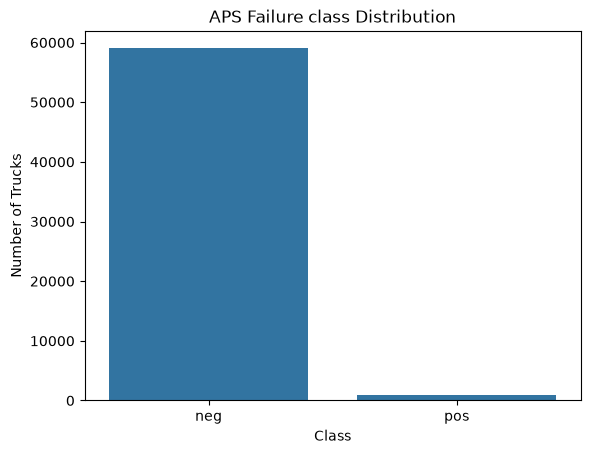

In [5]:
sns.countplot(data=df_eda,x="class")
plt.title("APS Failure class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Trucks")
plt.show()

### Observation

The dataset is highly imbalanced.

The `neg` class contains most of the observations, while the `pos` class
contains a much smaller number of APS failure cases.

This class imbalance will be handled later during preprocessing.

## 7. Missing Value Analysis

The APS dataset contains many missing values.

Let's find the percentage of missing values in each column.

In [9]:
missing_percentage = df_eda.isnull().mean() * 100

missing_percentage.sort_values(ascending=False).head(20)

br_000    82.106667
bq_000    81.203333
bp_000    79.566667
bo_000    77.221667
ab_000    77.215000
cr_000    77.215000
bn_000    73.348333
bm_000    65.915000
bl_000    45.461667
bk_000    38.390000
ad_000    24.768333
cg_000    24.768333
ch_000    24.768333
cf_000    24.768333
co_000    24.768333
cx_000    23.013333
cz_000    23.013333
cy_000    23.013333
dc_000    23.013333
db_000    23.013333
dtype: float64

## 8. Visualize Missing Values

We will visualize the 20 features with the highest percentage of missing values.

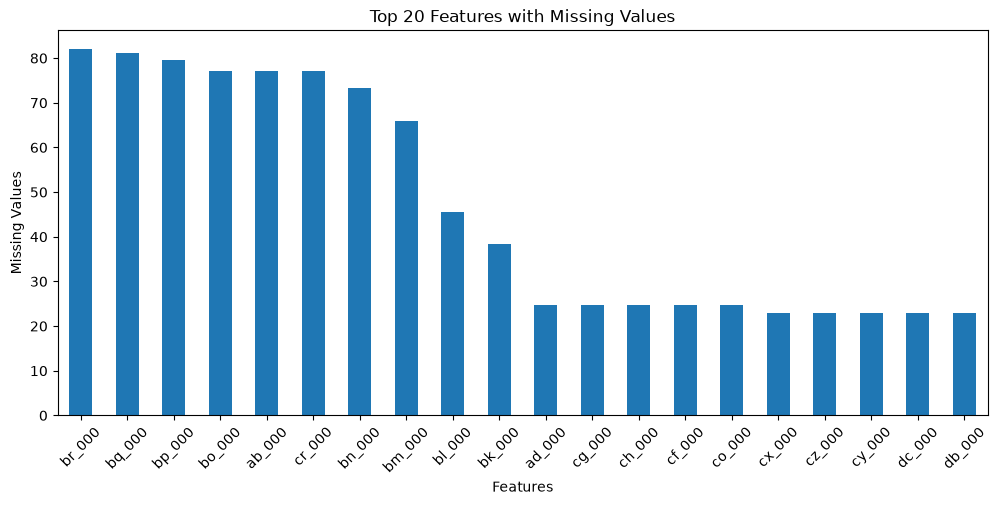

In [15]:
missing_percentage.sort_values(ascending=False).head(20).plot(kind="bar",figsize=(12,5))

plt.title("Top 20 Features with Missing Values")
plt.xlabel("Features")
plt.ylabel("Missing Values")
plt.xticks(rotation=45)
plt.show()

## 9. Feature Distribution

The dataset contains 170 sensor features.

Instead of plotting all 170 features, we will look at a few selected features.

In [16]:
features_to_plot = [ "aa_000","ac_000","ag_000","ah_000", "ay_000"]

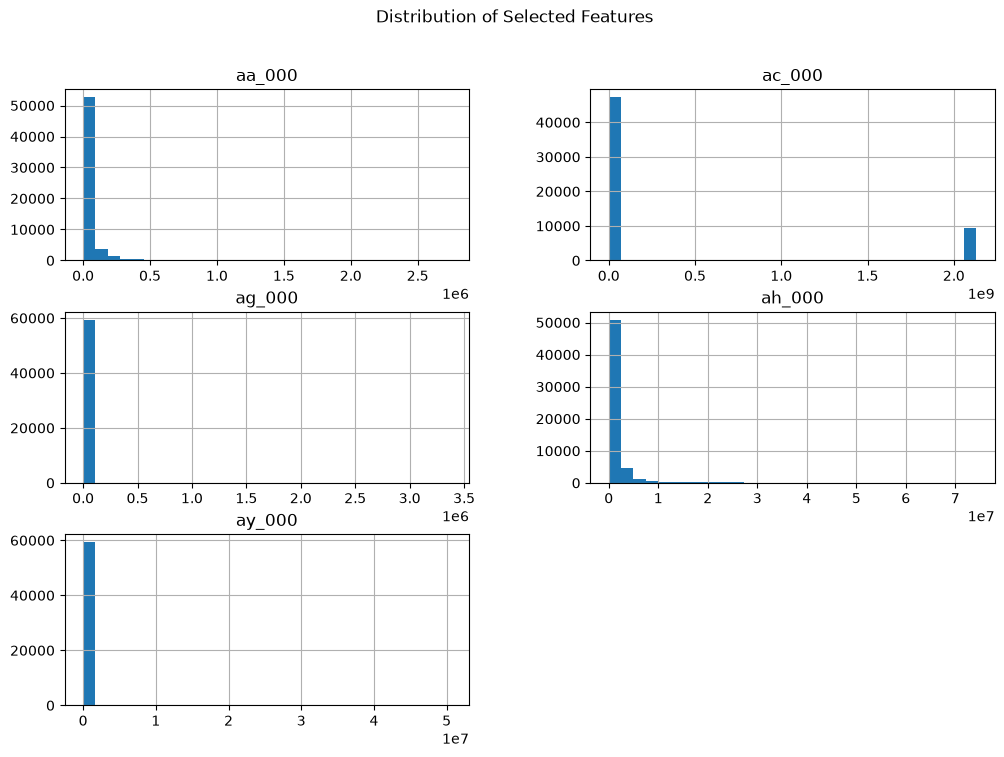

In [17]:
df_eda[features_to_plot].hist(figsize=(12, 8),bins=30)

plt.suptitle("Distribution of Selected Features")

plt.show()

## 10. Outlier Analysis

A boxplot helps us identify unusually high or low values.

We will check some selected sensor features.

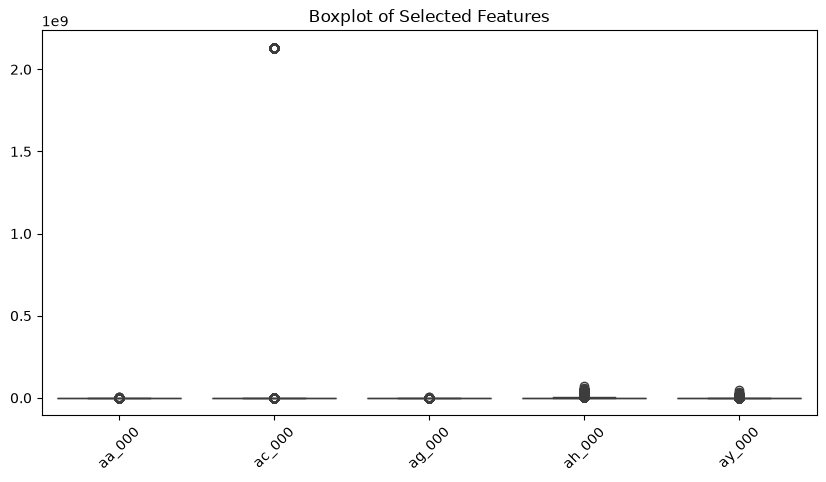

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_eda[features_to_plot])

plt.title("Boxplot of Selected Features")
plt.xticks(rotation=45)

plt.show()

### Observation

Some features contain extreme values.

These values should not be removed automatically because extreme sensor
measurements may contain useful information about APS failures.

We will consider them during preprocessing and model development.

## 11. Feature Variance

Variance tells us how much the values of a feature change.

Features with extremely low variance may provide little useful information.

In [19]:
x=df_eda.drop(columns=["class"])
var=x.var()
var.sort_values().head(20)

cd_000    0.000000e+00
ch_000    8.859750e-04
ab_000    1.210318e+01
ef_000    1.908690e+01
ar_000    3.037832e+01
eg_000    7.798022e+01
dz_000    1.170948e+02
ea_000    2.865324e+03
db_000    5.388384e+03
ae_000    2.609626e+04
da_000    3.628576e+04
af_000    4.401293e+04
cg_000    1.381614e+05
bf_000    2.989789e+05
cr_000    1.054732e+06
ax_000    2.198434e+06
de_000    2.852931e+06
cm_000    2.867480e+06
cs_001    8.330909e+06
az_009    1.060525e+07
dtype: float64

## 12. Features with Highest Variance

In [20]:
var.sort_values(ascending=False).head(20)

ac_000    6.318261e+17
dq_000    9.503282e+15
eb_000    1.827284e+15
cf_000    1.632517e+15
co_000    1.632517e+15
ad_000    1.632516e+15
du_000    1.338133e+14
bb_000    1.185210e+14
bv_000    1.179375e+14
cq_000    1.179375e+14
bu_000    1.179375e+14
bx_000    1.071543e+14
cc_000    9.265357e+13
ci_000    6.982269e+13
an_000    6.068955e+13
ao_000    4.650583e+13
az_005    4.173445e+13
cs_005    3.151188e+13
ay_007    2.607305e+13
ah_000    1.752042e+13
dtype: float64

## 13. Correlation Analysis

Correlation tells us how strongly two numerical features are related.

We will check the correlation between a few selected features.

In [21]:
corr=df_eda[features_to_plot].corr()
corr

,aa_000,ac_000,ag_000,ah_000,ay_000
aa_000,1.000000,-0.032055,0.018610,0.908103,0.057891
ac_000,-0.032055,1.000000,0.017620,-0.041149,-0.008654
ag_000,0.018610,0.017620,1.000000,0.021002,-0.000238
ah_000,0.908103,-0.041149,0.021002,1.000000,0.105182
ay_000,0.057891,-0.008654,-0.000238,0.105182,1.000000


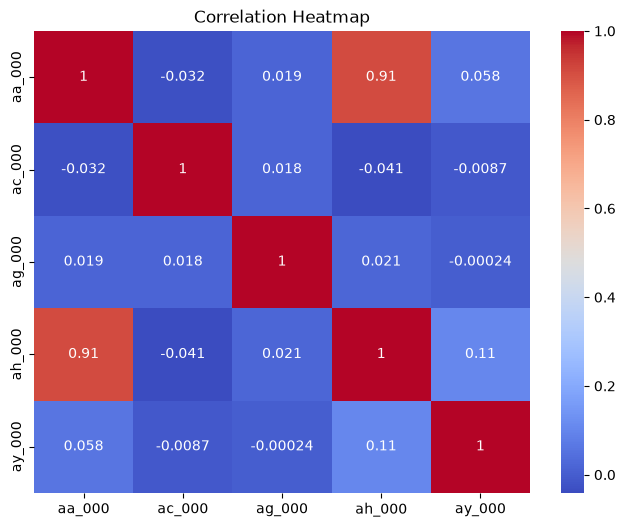

In [22]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## 14. Feature vs Target

Now we will compare sensor values between:

- `neg` → No APS failure
- `pos` → APS failure

This helps us understand whether some features behave differently for
failure and non-failure cases.

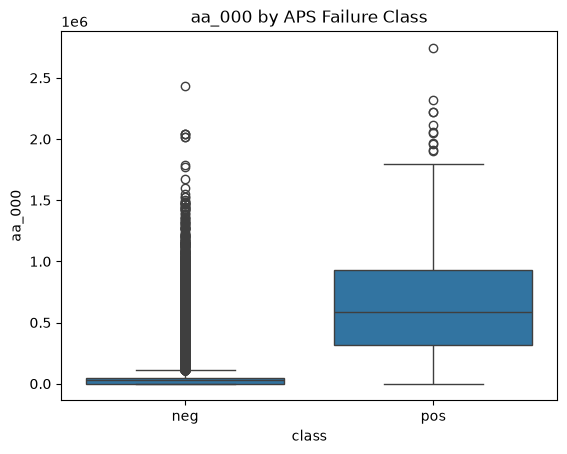

In [23]:
sns.boxplot(
    data=df_eda,
    x="class",
    y="aa_000"
)

plt.title("aa_000 by APS Failure Class")

plt.show()

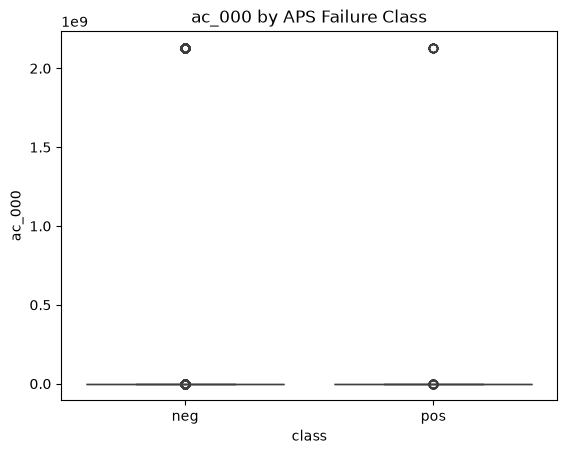

In [24]:
sns.boxplot(
    data=df_eda,
    x="class",
    y="ac_000"
)

plt.title("ac_000 by APS Failure Class")

plt.show()

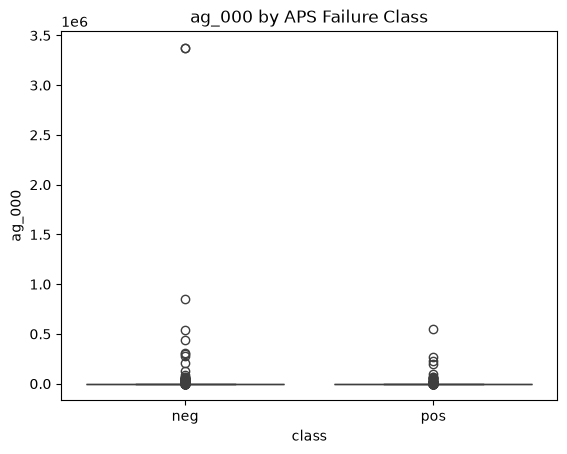

In [25]:
sns.boxplot(
    data=df_eda,
    x="class",
    y="ag_000"
)

plt.title("ag_000 by APS Failure Class")

plt.show()